# Comparing Sequential XGBoost and LSTM models

In [143]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

XGB_FILE = Path("xgb_predictions.parquet")
LSTM_FILE = Path("lstm_predictions.npz")

#### Helper Functions

In [144]:
def binary_metrics(y_true, probs):
    preds = (probs >= 0.5).astype(int)

    return {
        "auc": roc_auc_score(y_true, probs),
        "log_loss": log_loss(y_true, probs, labels=[0, 1]),
        "accuracy": accuracy_score(y_true, preds),
        "rows": len(y_true),
    }


def print_metrics(name, metrics):
    print(name)
    print("AUC:      ", round(metrics["auc"], 4))
    print("Log loss: ", round(metrics["log_loss"], 4))
    print("Accuracy: ", round(metrics["accuracy"], 4))
    print("Rows:     ", metrics["rows"])

## Load Predictions

In [145]:
xgb = pd.read_parquet(XGB_FILE)

xgb = xgb.rename(columns={
    "pred_prob_team_100_win": "prob",
    "target": "y",
})

xgb = xgb[["match_id", "minute", "y", "prob"]].copy()
xgb["model"] = "XGBoost"

xgb.head()

lstm_data = np.load(LSTM_FILE, allow_pickle=True)

lstm_probs = lstm_data["probs_test"]
lstm_y = lstm_data["y_test"]
lstm_mask = lstm_data["mask_test"]
lstm_match_ids = lstm_data["match_ids_test"]

rows = []

for i in range(len(lstm_y)):
    for t in range(lstm_probs.shape[1]):
        if lstm_mask[i, t] == 1:
            rows.append({
                "match_id": str(lstm_match_ids[i]),
                "minute": t + 1,
                "y": int(lstm_y[i]),
                "prob": float(lstm_probs[i, t]),
                "model": "LSTM",
            })

lstm = pd.DataFrame(rows)

lstm.head()

,match_id,minute,y,prob,model
0,NA1_5593795028,1,1,0.489661,LSTM
1,NA1_5593795028,2,1,0.456793,LSTM
2,NA1_5593795028,3,1,0.391679,LSTM
3,NA1_5593795028,4,1,0.409538,LSTM
4,NA1_5593795028,5,1,0.356240,LSTM


## Comparison

In [146]:
xgb_metrics = binary_metrics(xgb["y"], xgb["prob"])
lstm_metrics = binary_metrics(lstm["y"], lstm["prob"])

print_metrics("XGBoost every-minute", xgb_metrics)
print()
print_metrics("LSTM every-minute", lstm_metrics)

comparison = pd.DataFrame([
    {"model": "XGBoost", **xgb_metrics},
    {"model": "LSTM", **lstm_metrics},
])

comparison


XGBoost every-minute
AUC:       0.807
Log loss:  0.5284
Accuracy:  0.7175
Rows:      57833

LSTM every-minute
AUC:       0.8028
Log loss:  0.5332
Accuracy:  0.7139
Rows:      57591


,model,auc,log_loss,accuracy,rows
0,XGBoost,0.807000,0.528432,0.717462,57833
1,LSTM,0.802836,0.533197,0.713862,57591


## Evaluation by minute

In [147]:
def add_minute_bucket(df):
    bins = [0, 5, 10, 15, 20, 25, 30, 45]
    labels = ["1-5", "6-10", "11-15", "16-20", "21-25", "26-30", "31-45"]

    df = df.copy()
    df["minute_bucket"] = pd.cut(
        df["minute"],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True,
    )

    return df


xgb_b = add_minute_bucket(xgb)
lstm_b = add_minute_bucket(lstm)

both = pd.concat([xgb_b, lstm_b], ignore_index=True)

bucket_rows = []

for model_name, model_df in both.groupby("model"):
    for bucket, g in model_df.groupby("minute_bucket", observed=True):
        if len(g) == 0 or g["y"].nunique() < 2:
            continue

        metrics = binary_metrics(g["y"], g["prob"])

        bucket_rows.append({
            "model": model_name,
            "minute_bucket": bucket,
            **metrics,
        })

bucket_results = pd.DataFrame(bucket_rows)

bucket_results

,model,minute_bucket,auc,log_loss,accuracy,rows
0,LSTM,1-5,0.582330,0.680716,0.553884,9641
1,LSTM,6-10,0.701644,0.626590,0.640162,9382
2,LSTM,11-15,0.784761,0.558030,0.709314,9309
3,LSTM,16-20,0.842558,0.491986,0.760192,8953
4,LSTM,21-25,0.885227,0.426724,0.802599,8156
5,LSTM,26-30,0.900435,0.402158,0.817047,6406
6,LSTM,31-45,0.875923,0.454362,0.796831,5744
7,XGBoost,1-5,0.601266,0.673641,0.565093,11522
8,XGBoost,6-10,0.727768,0.608993,0.664460,9367
9,XGBoost,11-15,0.807981,0.531896,0.729991,9296


### AUC by minute bucket

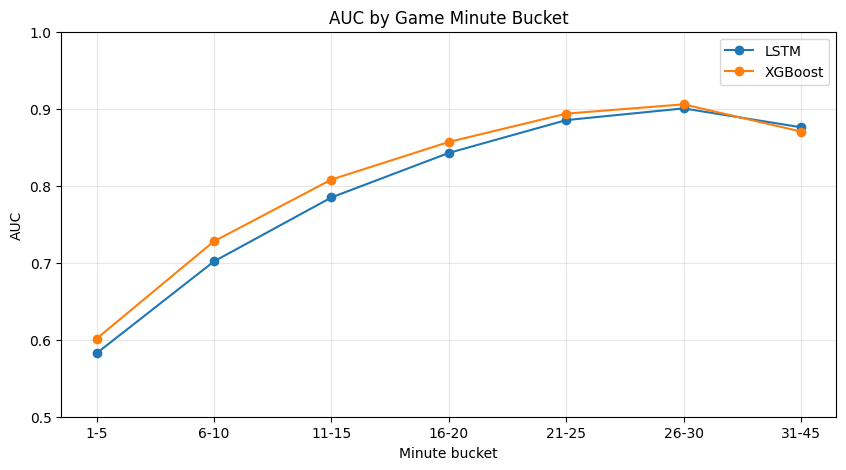

In [148]:
plt.figure(figsize=(10, 5))

for model_name, g in bucket_results.groupby("model"):
    plt.plot(
        g["minute_bucket"].astype(str),
        g["auc"],
        marker="o",
        label=model_name,
    )

plt.title("AUC by Game Minute Bucket")
plt.xlabel("Minute bucket")
plt.ylabel("AUC")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Accuracy by minute bucket

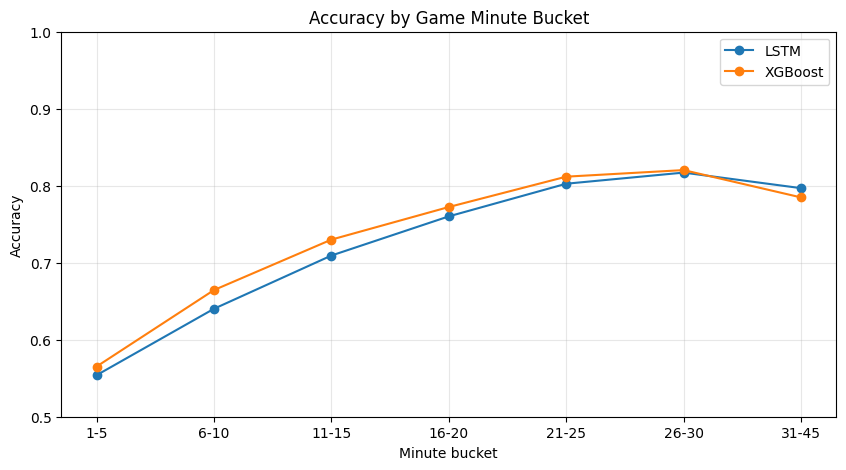

In [149]:
plt.figure(figsize=(10, 5))

for model_name, g in bucket_results.groupby("model"):
    plt.plot(
        g["minute_bucket"].astype(str),
        g["accuracy"],
        marker="o",
        label=model_name,
    )

plt.title("Accuracy by Game Minute Bucket")
plt.xlabel("Minute bucket")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Probability Distribution

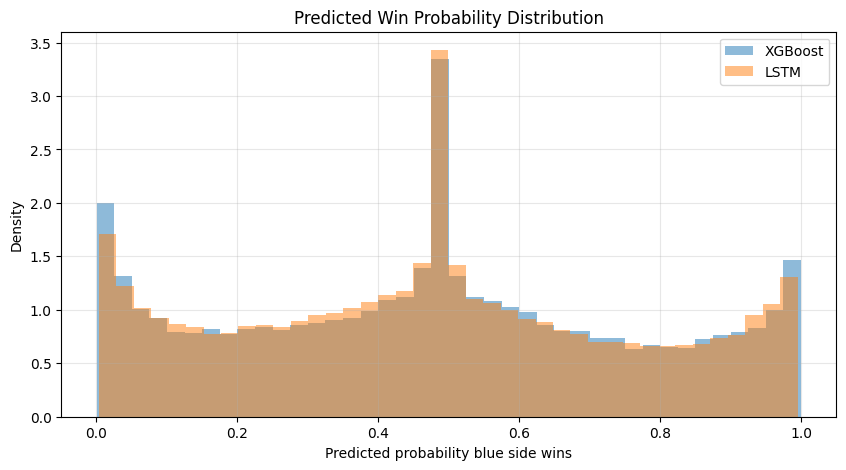

In [150]:
plt.figure(figsize=(10, 5))

plt.hist(
    xgb["prob"],
    bins=40,
    alpha=0.5,
    label="XGBoost",
    density=True,
)

plt.hist(
    lstm["prob"],
    bins=40,
    alpha=0.5,
    label="LSTM",
    density=True,
)

plt.title("Predicted Win Probability Distribution")
plt.xlabel("Predicted probability blue side wins")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Confidence

In [151]:
all_preds = pd.concat([xgb, lstm], ignore_index=True)

all_preds["minute"] = all_preds["minute"].round().astype(int)

all_preds = all_preds[
    (all_preds["minute"] >= 1)
    & (all_preds["minute"] <= 45)
].copy()

all_preds["confidence"] = (all_preds["prob"] - 0.5).abs() * 2

confidence_by_minute = (
    all_preds
    .groupby(["model", "minute"], as_index=False)
    .agg(
        confidence=("confidence", "mean"),
        rows=("confidence", "size"),
    )
)

confidence_by_minute.head()

,model,minute,confidence,rows
0,LSTM,1,0.020679,1955
1,LSTM,2,0.041076,1955
2,LSTM,3,0.129322,1955
3,LSTM,4,0.177267,1890
4,LSTM,5,0.230211,1886


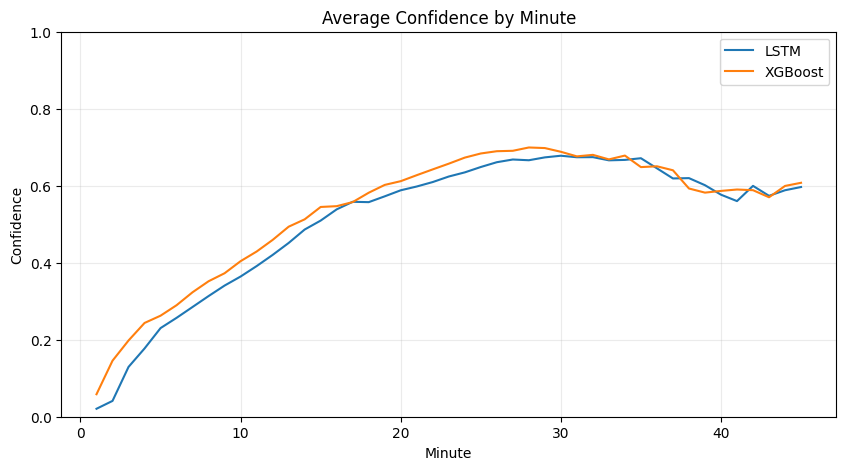

In [152]:
plt.figure(figsize=(10, 5))

for model in confidence_by_minute["model"].unique():
    g = confidence_by_minute[confidence_by_minute["model"] == model]

    plt.plot(
        g["minute"],
        g["confidence"],
        label=model,
    )

plt.xlabel("Minute")
plt.ylabel("Confidence")
plt.title("Average Confidence by Minute")
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## XGBoost Feature Importance

In [153]:
import xgboost as xgb_model

model = xgb_model.XGBClassifier()
model.load_model("xgb_model.json")

importances = pd.DataFrame({
    "feature": model.get_booster().feature_names,
    "importance": model.feature_importances_,
})

importances = importances.sort_values("importance", ascending=False)

display(importances.head(25))

,feature,importance
399,team_total_gold_diff,0.114584
104,gold_diff_per_min,0.065335
343,team_100_gold_share,0.061989
417,team_xp_diff,0.027854
507,xp_diff_per_min,0.027454
372,team_level_diff,0.015908
92,dragons_diff,0.010267
401,team_total_gold_diff_delta_3min,0.010214
365,team_deaths_diff_delta_3min,0.009038
269,nexus_tower_2_200_destroyed,0.007323


In [154]:
full_df = pd.read_parquet("data/full_dataset.parquet")

rank_map = (
    full_df[["match_id", "rank"]]
    .drop_duplicates()
    .copy()
)

rank_map["match_id"] = rank_map["match_id"].astype(str)
paired["match_id"] = paired["match_id"].astype(str)

paired_rank = paired.merge(rank_map, on="match_id", how="left")

paired_rank["xgb_confidence"] = (paired_rank["prob_xgb"] - 0.5).abs() * 2
paired_rank["lstm_confidence"] = (paired_rank["prob_lstm"] - 0.5).abs() * 2

rank_summary = (
    paired_rank
    .groupby("rank", as_index=False)
    .agg(
        matches=("match_id", "nunique"),
        rows=("match_id", "size"),
        xgb_log_loss=("xgb_loss", "mean"),
        lstm_log_loss=("lstm_loss", "mean"),
        xgb_confidence=("xgb_confidence", "mean"),
        lstm_confidence=("lstm_confidence", "mean"),
    )
)

rank_summary["log_loss_diff_xgb_minus_lstm"] = (
    rank_summary["xgb_log_loss"] - rank_summary["lstm_log_loss"]
)

rank_summary["confidence_diff_xgb_minus_lstm"] = (
    rank_summary["xgb_confidence"] - rank_summary["lstm_confidence"]
)

rank_order = [
    "IRON",
    "BRONZE",
    "SILVER",
    "GOLD",
    "PLATINUM",
    "EMERALD",
    "DIAMOND",
    "MASTER",
    "GRANDMASTER",
    "CHALLENGER",
]

rank_summary["rank"] = pd.Categorical(
    rank_summary["rank"],
    categories=rank_order,
    ordered=True,
)

rank_summary = rank_summary.sort_values("rank")

display(rank_summary)

,rank,matches,rows,xgb_log_loss,lstm_log_loss,xgb_confidence,lstm_confidence,log_loss_diff_xgb_minus_lstm,confidence_diff_xgb_minus_lstm
6,IRON,218,6220,0.438510,0.473690,0.499356,0.451645,-0.035180,0.047711
0,BRONZE,187,5606,0.547092,0.572112,0.482405,0.434427,-0.025020,0.047978
9,SILVER,189,5435,0.506978,0.534895,0.499822,0.457500,-0.027917,0.042322
4,GOLD,193,5571,0.534319,0.568542,0.486794,0.446541,-0.034223,0.040253
8,PLATINUM,216,6208,0.499286,0.526899,0.488770,0.445028,-0.027613,0.043742
3,EMERALD,226,6763,0.605292,0.624296,0.478390,0.438453,-0.019004,0.039937
2,DIAMOND,192,5388,0.543947,0.563586,0.486321,0.452251,-0.019639,0.034071
7,MASTER,177,4966,0.540135,0.573422,0.465101,0.420653,-0.033287,0.044448
5,GRANDMASTER,220,5817,0.480727,0.515867,0.487347,0.440108,-0.035140,0.047239
1,CHALLENGER,137,3714,0.513393,0.544560,0.477982,0.438899,-0.031167,0.039084


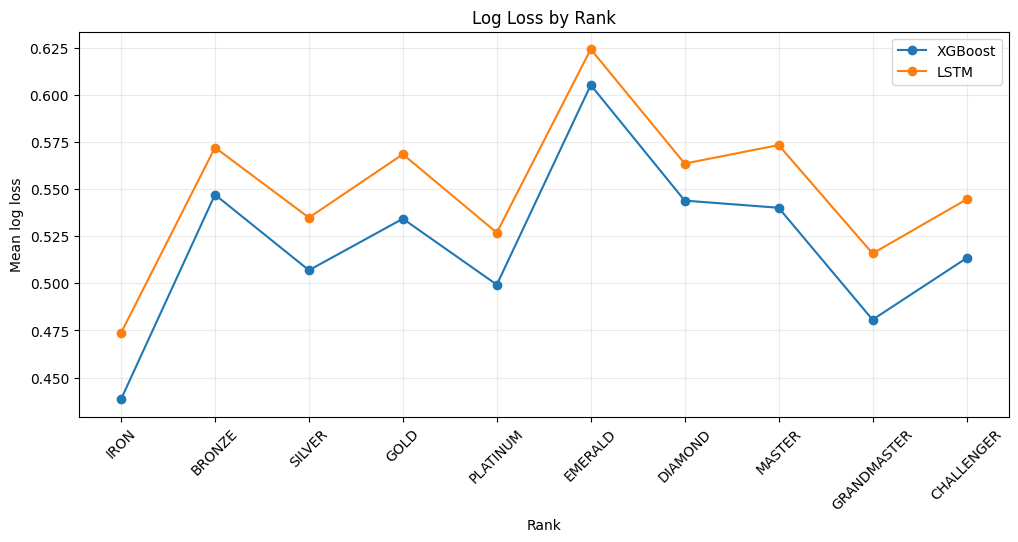

In [155]:
plt.figure(figsize=(12, 5))

plt.plot(rank_summary["rank"], rank_summary["xgb_log_loss"], marker="o", label="XGBoost")
plt.plot(rank_summary["rank"], rank_summary["lstm_log_loss"], marker="o", label="LSTM")

plt.xlabel("Rank")
plt.ylabel("Mean log loss")
plt.title("Log Loss by Rank")
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

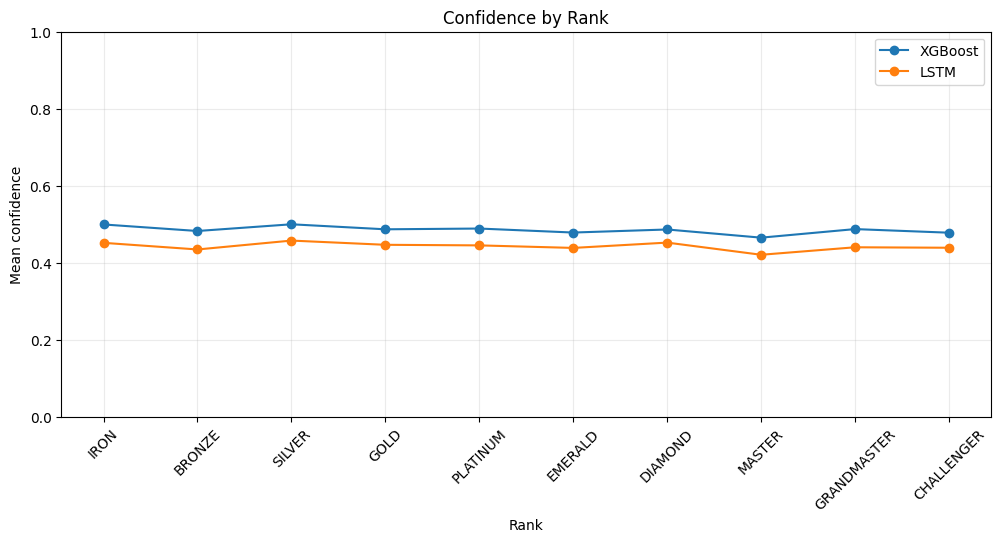

In [156]:
plt.figure(figsize=(12, 5))

plt.plot(rank_summary["rank"], rank_summary["xgb_confidence"], marker="o", label="XGBoost")
plt.plot(rank_summary["rank"], rank_summary["lstm_confidence"], marker="o", label="LSTM")

plt.xlabel("Rank")
plt.ylabel("Mean confidence")
plt.title("Confidence by Rank")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [157]:
from scipy.stats import f_oneway

rank_order = [
    "IRON", "BRONZE", "SILVER", "GOLD", "PLATINUM",
    "EMERALD", "DIAMOND", "MASTER", "GRANDMASTER", "CHALLENGER"
]

xgb_groups = [
    paired_rank.loc[paired_rank["rank"] == rank, "xgb_confidence"].dropna()
    for rank in rank_order
]

lstm_groups = [
    paired_rank.loc[paired_rank["rank"] == rank, "lstm_confidence"].dropna()
    for rank in rank_order
]

xgb_groups = [g for g in xgb_groups if len(g) > 1]
lstm_groups = [g for g in lstm_groups if len(g) > 1]

xgb_f, xgb_p = f_oneway(*xgb_groups)
lstm_f, lstm_p = f_oneway(*lstm_groups)

print("XGBoost confidence ANOVA")
print("F-stat:", xgb_f)
print("p-value:", xgb_p)

print()

print("LSTM confidence ANOVA")
print("F-stat:", lstm_f)
print("p-value:", lstm_p)

XGBoost confidence ANOVA
F-stat: 5.4772153
p-value: 1.4731788e-07

LSTM confidence ANOVA
F-stat: 6.013746167994262
p-value: 1.8063145935714538e-08


## Tests for significance

### Log Loss

In [158]:
from scipy.stats import ttest_rel
import numpy as np

xgb["minute"] = xgb["minute"].round().astype(int)
lstm["minute"] = lstm["minute"].round().astype(int)
xgb["match_id"] = xgb["match_id"].astype(str)
lstm["match_id"] = lstm["match_id"].astype(str)

paired = xgb.merge(
    lstm,
    on=["match_id", "minute"],
    suffixes=("_xgb", "_lstm"),
)

paired["y"] = paired["y_xgb"]

eps = 1e-15
paired["prob_xgb"] = paired["prob_xgb"].clip(eps, 1 - eps)
paired["prob_lstm"] = paired["prob_lstm"].clip(eps, 1 - eps)

paired["xgb_loss"] = -(
    paired["y"] * np.log(paired["prob_xgb"])
    + (1 - paired["y"]) * np.log(1 - paired["prob_xgb"])
)

paired["lstm_loss"] = -(
    paired["y"] * np.log(paired["prob_lstm"])
    + (1 - paired["y"]) * np.log(1 - paired["prob_lstm"])
)

match_loss = paired.groupby("match_id")[["xgb_loss", "lstm_loss"]].mean()

t_stat, p_value = ttest_rel(
    match_loss["xgb_loss"],
    match_loss["lstm_loss"],
)

print("XGB mean log loss:", match_loss["xgb_loss"].mean())
print("LSTM mean log loss:", match_loss["lstm_loss"].mean())
print("t-stat:", t_stat)
print("p-value:", p_value)

XGB mean log loss: 0.49163362
LSTM mean log loss: 0.528249145574056
t-stat: -13.53317237444809
p-value: 5.925722258115252e-40


### Confidence

In [159]:
paired["xgb_confidence"] = (paired["prob_xgb"] - 0.5).abs() * 2
paired["lstm_confidence"] = (paired["prob_lstm"] - 0.5).abs() * 2

match_conf = paired.groupby("match_id")[["xgb_confidence", "lstm_confidence"]].mean()

t_stat, p_value = ttest_rel(
    match_conf["xgb_confidence"],
    match_conf["lstm_confidence"],
)

print("XGB mean confidence:", match_conf["xgb_confidence"].mean())
print("LSTM mean confidence:", match_conf["lstm_confidence"].mean())
print("t-stat:", t_stat)
print("p-value:", p_value)

XGB mean confidence: 0.48439738
LSTM mean confidence: 0.4316470795599487
t-stat: 30.02022557198328
p-value: 3.807810174850749e-163


### Disagreement

Disagreement rate: 0.1471412153426232


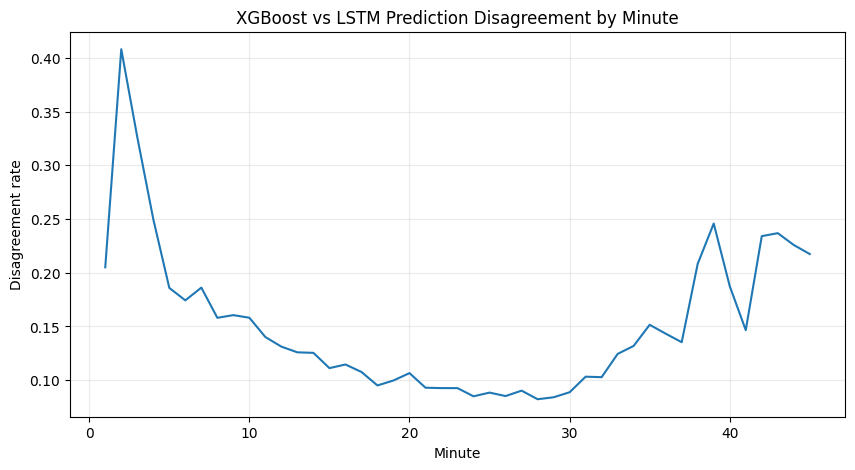

In [160]:
paired["xgb_pred"] = (paired["prob_xgb"] >= 0.5).astype(int)
paired["lstm_pred"] = (paired["prob_lstm"] >= 0.5).astype(int)

paired["disagree"] = paired["xgb_pred"] != paired["lstm_pred"]

print("Disagreement rate:", paired["disagree"].mean())

disagree_by_minute = (
    paired
    .groupby("minute", as_index=False)
    .agg(disagreement_rate=("disagree", "mean"))
)

plt.figure(figsize=(10, 5))
plt.plot(disagree_by_minute["minute"], disagree_by_minute["disagreement_rate"])
plt.xlabel("Minute")
plt.ylabel("Disagreement rate")
plt.title("XGBoost vs LSTM Prediction Disagreement by Minute")
plt.grid(alpha=0.25)
plt.show()

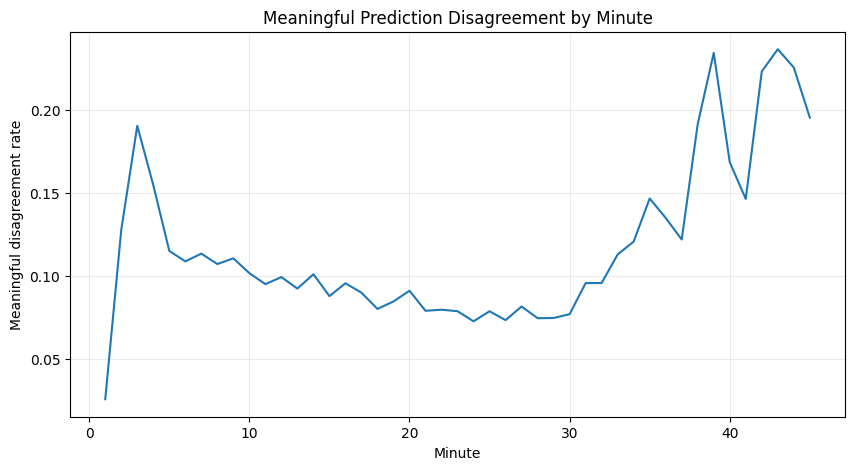

In [161]:
paired["meaningful_disagree"] = (
    (paired["xgb_pred"] != paired["lstm_pred"])
    & ((paired["prob_xgb"] - paired["prob_lstm"]).abs() >= 0.10)
)

meaningful_by_minute = (
    paired
    .groupby("minute", as_index=False)
    .agg(meaningful_disagreement_rate=("meaningful_disagree", "mean"))
)

plt.figure(figsize=(10, 5))
plt.plot(
    meaningful_by_minute["minute"],
    meaningful_by_minute["meaningful_disagreement_rate"],
)
plt.xlabel("Minute")
plt.ylabel("Meaningful disagreement rate")
plt.title("Meaningful Prediction Disagreement by Minute")
plt.grid(alpha=0.25)
plt.show()

### By Bucket

In [162]:
buckets = [
    (1, 5),
    (6, 10),
    (11, 15),
    (16, 20),
    (21, 25),
    (26, 30),
    (31, 45),
]

for start, end in buckets:
    g = paired[(paired["minute"] >= start) & (paired["minute"] <= end)].copy()

    if g.empty:
        continue

    match_bucket = g.groupby("match_id")[["xgb_loss", "lstm_loss"]].mean()

    if len(match_bucket) < 2:
        continue

    t_stat, p_value = ttest_rel(
        match_bucket["xgb_loss"],
        match_bucket["lstm_loss"],
    )

    print(f"Minutes {start}-{end}")
    print("XGB log loss:", match_bucket["xgb_loss"].mean())
    print("LSTM log loss:", match_bucket["lstm_loss"].mean())
    print("p-value:", p_value)
    print()

Minutes 1-5
XGB log loss: 0.66561186
LSTM log loss: 0.6813742149448919
p-value: 2.0626205852021623e-11

Minutes 6-10
XGB log loss: 0.6083558
LSTM log loss: 0.6267003921343209
p-value: 3.4124022043360347e-08

Minutes 11-15
XGB log loss: 0.5304744
LSTM log loss: 0.5574009184033734
p-value: 1.7001013846032724e-11

Minutes 16-20
XGB log loss: 0.4626955
LSTM log loss: 0.49110783567347277
p-value: 2.1072623475320077e-09

Minutes 21-25
XGB log loss: 0.39746693
LSTM log loss: 0.42437531505486004
p-value: 2.2867907090205358e-07

Minutes 26-30
XGB log loss: 0.348707
LSTM log loss: 0.39507187598125537
p-value: 1.0666572891872819e-13

Minutes 31-45
XGB log loss: 0.3149238
LSTM log loss: 0.4066740710570009
p-value: 4.251547292216435e-19



## Rank Stratified

## Summary

In [163]:
summary = comparison[["model", "auc", "log_loss", "accuracy", "rows"]].copy()
summary = summary.sort_values("auc", ascending=False)

summary

,model,auc,log_loss,accuracy,rows
0,XGBoost,0.807000,0.528432,0.717462,57833
1,LSTM,0.802836,0.533197,0.713862,57591
